# Standard incomplete markets model: steady state and calibration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
import json

import sim_steady_state_fast as sim

In [2]:
# for plotting: uncomment second line to get plots with exact style
plt.rcParams.update({'font.size': 10, 'font.family': 'serif', 'figure.figsize': (6, 3)})
plt.rcParams.update({'text.usetex': True, 'font.serif': 'Palatino'})

## Core calibration and example steady state

In [3]:
rho_e = 0.91**(1/4)     # annual rho=0.91 from IKC
sd_e = 0.92             # cross-sectional sd from IKC
n_e = 11                # 11 points for Rouwenhorst approximation

e, pi_e, Pi_e = sim.discretize_income(rho_e, sd_e, n_e)

min_a = 0               # borrowing constraint of 0 (no borrowing)
max_a = 4000
n_a = 400
a_grid = sim.discretize_assets(min_a, max_a, n_a)

r = 0.02/4              # annual r=2% from ARE
beta = 0.985            # arbitrary discount factor prior to exact calibration
eis = 1                 # elasticity of intertemporal substitution = 1 (log utility)

calib = dict(a_grid=a_grid, y=e, Pi=Pi_e, r=r, beta=beta, eis=eis)
ss = sim.steady_state(**calib)
ss['A'] / 4 # report annualized assets over income

np.float64(2.760508428637381)

## Examples: visualizing consumption policy functions
Look at the lower endowment states so that the concavity is more visible.

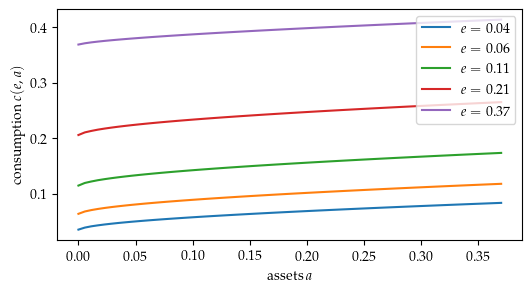

In [4]:
for ei, ee in enumerate(e[:5]):
    plt.plot(a_grid[:50], ss['c'][ei, :50], label=rf'$e={ee:.2f}$')
plt.legend()
plt.xlabel(r'assets $a$')
plt.ylabel(r'consumption $c(e,a)$')
plt.savefig("figures/lecture1_fig1.pdf", transparent=True, bbox_inches='tight')

### Visualizing associated savings functions

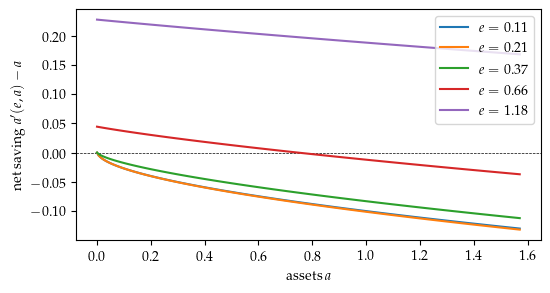

In [5]:
ia = 120
plt.axhline(0, color='k', linestyle='--', linewidth=0.5)
for ei, ee in enumerate(e):
    if 2 <= ei <= 6:
        plt.plot(a_grid[:ia], ss['a'][ei, :ia] - a_grid[:ia], label=rf'$e={ee:.2f}$')
plt.legend()
plt.xlabel(r'assets $a$')
plt.ylabel(r"net saving $a'(e,a)-a$")
plt.savefig("figures/lecture1_fig2.pdf", transparent=True, bbox_inches='tight')

### Visualizing distributions

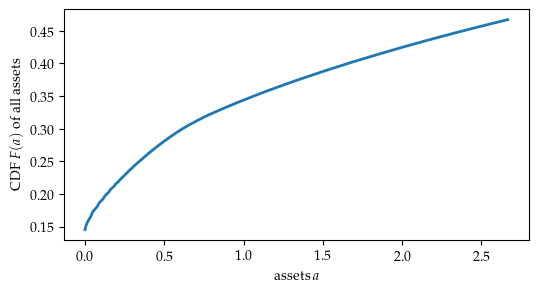

In [6]:
Fa = ss['D'].sum(axis=0).cumsum()
plt.plot(a_grid[:150], Fa[:150], linewidth=2)
plt.xlabel(r'assets $a$')
plt.ylabel(r"CDF $F(a)$ of all assets")
plt.savefig("figures/lecture1_fig3.pdf", transparent=True, bbox_inches='tight')

## Asset-MPC tradeoff
First write code that numerically calculates MPCs at each point by differentiating the backward iteration:

In [7]:
def get_mpcs(ss, h=1e-4):
    kwargs = {k: ss[k] for k in ('Va', 'Pi', 'a_grid', 'r', 'beta', 'eis')}
    # c0 in principle equals ss['c'], but we want to avoid any error
    # from ss not having fully converged (it's blown up when dividing by h)
    c0 = sim.backward_iteration(y=ss['y'], **kwargs)[2]
    c1 = sim.backward_iteration(y=ss['y'] + h, **kwargs)[2]
    return (c1 - c0) / (h if np.isscalar(h) else h[:, np.newaxis])

Now setting $Z=0.7$, calibrating different $\beta$:

In [8]:
calib['y'] = 0.7*e
betas = [0.9, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, *np.linspace(0.982, 0.992, 10)]

As, MPCs_inc, MPCs_unw = [], [], []
for beta in betas:
    ss = sim.steady_state(**{**calib, 'beta': beta})
    As.append(ss['A'])
    mpcs = get_mpcs(ss)
    MPCs_inc.append((ss['D'] * mpcs * e[:, np.newaxis]).sum()) # income-weighted average
    MPCs_unw.append((ss['D'] * mpcs).sum())                    # unweighted average
As = np.array(As) / 4 # annualize assets

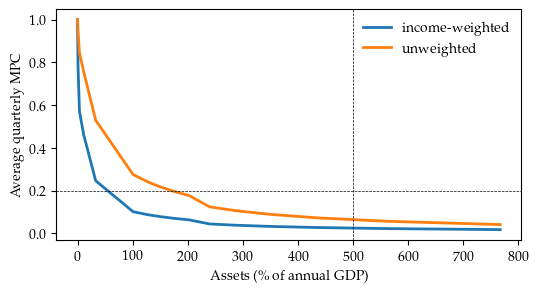

In [9]:
plt.plot(100*As, MPCs_inc, linewidth=2, label='income-weighted')
plt.plot(100*As, MPCs_unw, linewidth=2, label='unweighted')
plt.legend(frameon=False)
plt.axhline(0.2, color='k', linestyle='--', linewidth=0.5)
plt.axvline(500, color='k', linestyle='--', linewidth=0.5)

plt.xlabel(r'Assets (\% of annual GDP)')
plt.ylabel(r"Average quarterly MPC")

plt.savefig("figures/lecture1_fig4.pdf", transparent=True, bbox_inches='tight')

## Calibration with $\beta$ heterogeneity

Transition matrix for $\beta$:

In [10]:
q = 0.01        # draw new beta every 25 years
pi_b = np.array([1/4, 1/4, 1/4, 1/4])
Pi_b = (1-q)*np.eye(4) + q*np.outer(np.ones(4), pi_b)

Get transition matrix for combined state, plus augmented $e$ vector:

In [11]:
Pi = np.kron(Pi_b, Pi_e)
e = np.kron(np.ones(4), e)
calib.update({'Pi': Pi, 'y': 0.7*e})

Function mapping vector `x` with the middle $\beta$ and gap into a `beta` that enters into our steady-state function:

In [12]:
def construct_beta(x):
    beta = np.kron([x[0]-3*x[1], x[0]-2*x[1], x[0]-x[1], x[0]], np.ones(n_e)) # 
    return beta[:, np.newaxis]      # need it to be column vector for backward_iteration() to work unchanged

Hit both calibration targets:

In [13]:
def evaluate_calibration(x, A_target, mpc_target):
    print(x)
    try:
        ss = sim.steady_state(**{**calib, 'beta': construct_beta(x)})
    except (ValueError, TypeError):
        # if steady state raises an error, likely because implied assets infinite
        return 10000, 0
    mpc_weighted = (ss['D'] * get_mpcs(ss, h=1e-4 * e) * e[:, np.newaxis]).sum()
    print(ss['A'], mpc_weighted)
    return ss['A'] - A_target, mpc_weighted - mpc_target

In [14]:
A_target = 5 * 4
mpc_target = 0.2
res = optimize.root(lambda x: evaluate_calibration(x, A_target, mpc_target),
                         np.array([1.0, 0.015]), tol=1E-9)
assert res.success

[1.    0.015]


13.561118943847529 0.1680969525280874
[1.    0.015]


13.561118943847529 0.1680969525280874
[1.    0.015]


13.561118943847529 0.1680969525280874
[1.00000001 0.015     ]


13.561167675846074 0.16809678032269332
[1.    0.015]


...

19.962743123284096 0.20004193416844057
[1.00228922 0.01926372]


20.00059080229154 0.1999997327702151
[1.00228912 0.01926363]


20.000009846913738 0.1999999955951584
[1.00228911 0.01926363]


20.000000001577504 0.19999999999990886
[1.00228911 0.01926363]


20.000000000016847 0.19999999999995416


In [15]:
beta_hi, dbeta = res.x
beta_hi, dbeta

(np.float64(1.0022891149186437), np.float64(0.019263626499695295))

Alternative calibration with fewer assets, which we'll use for our all-bond calibrations for the first few lectures. (Note that it still requires beta heterogeneity, but somewhat less extreme beta heterogeneity.)

In [16]:
A_target_lowA = 1 * 4
res = optimize.root(lambda x: evaluate_calibration(x, A_target_lowA, mpc_target),
                                            np.array([1.0, 0.015]), tol=1E-9)
assert res.success
beta_hi_lowA, dbeta_lowA = res.x
beta_hi_lowA, dbeta_lowA

[1.    0.015]


13.561118943847529 0.1680969525280874
[1.    0.015]


13.561118943847529 0.1680969525280874
[1.    0.015]


13.561118943847529 0.1680969525280874
[1.00000001 0.015     ]


13.561167675846074 0.16809678032269332
[1.    0.015]


...

4.000178689650052 0.20000039428663846
[0.99086847 0.01095959]


4.000028824357577 0.20000004326618576
[0.99086839 0.01095953]


4.000000991205678 0.20000000101947676
[0.99086838 0.01095953]


4.0000000208226965 0.20000000002151663
[0.99086838 0.01095953]


3.999999999995473 0.19999999999995996


Save the two calibrations for later notebooks:

In [17]:
betas = {
    'A_500': {'beta_hi': float(beta_hi), 'dbeta': float(dbeta)},
    'A_100': {'beta_hi': float(beta_hi_lowA), 'dbeta': float(dbeta_lowA)},
}
with open('betas.json', 'w') as f:
    json.dump(betas, f, indent=2)
betas

{'A_500': {'beta_hi': 1.0022891149186437, 'dbeta': 0.019263626499695295},
 'A_100': {'beta_hi': 0.9908683828230604, 'dbeta': 0.010959528277272156}}

## New tradeoff with heterogeneity

In [18]:
betas_hi = sorted([0.94, 0.96, 0.98, 0.985, 0.99, 0.995, beta_hi, *np.linspace(0.997, 1.004, 10)])
As_het, MPCs_inc_het = [], []
for beta_hi_cur in betas_hi:
    ss = sim.steady_state(**{**calib, 'beta': construct_beta(np.array([beta_hi_cur, dbeta]))})
    As_het.append(ss['A'])
    mpcs = get_mpcs(ss)
    MPCs_inc_het.append((ss['D'] * mpcs * e[:, np.newaxis]).sum()) # income-weighted average
As_het = np.array(As_het) / 4 # annualize assets

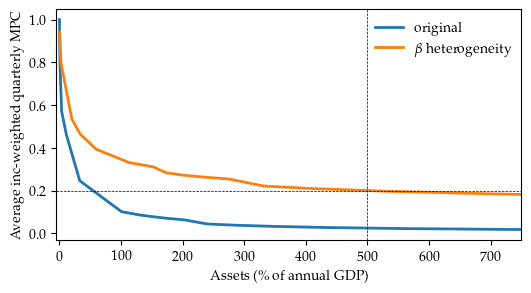

In [19]:
plt.plot(100*As, MPCs_inc, linewidth=2, label='original')
plt.plot(100*As_het, MPCs_inc_het, linewidth=2, label=r'$\beta$ heterogeneity')
plt.legend(frameon=False)
plt.xlim(-5, 750)
plt.axhline(0.2, color='k', linestyle='--', linewidth=0.5)
plt.axvline(500, color='k', linestyle='--', linewidth=0.5)

plt.xlabel(r'Assets (\% of annual GDP)')
plt.ylabel(r"Average inc-weighted quarterly MPC")

plt.savefig("figures/lecture1_fig5.pdf", transparent=True, bbox_inches='tight')

## Lorenz curve vs. US data

In [20]:
# load Lorenz curve in the 2019 SCF, interpolate to percentiles
lorenz_scf = np.loadtxt('inputs/lorenz_nw_scf_2019.raw', delimiter=',')

# get Lorenz curve implied by a given model steady state
def get_lorenz(ss, percentiles):
    D = ss['D'].sum(axis=0) # distribution over asset grid alone
    a_grid = ss['a_grid']
    lorenz_model = np.array([np.interp(pctl, D.cumsum(), (a_grid * D).cumsum()) / ss['A'] for pctl in percentiles])
    return lorenz_model

In [21]:
calib['beta'] = construct_beta(np.array([beta_hi, dbeta]))
ss = sim.steady_state(**calib)

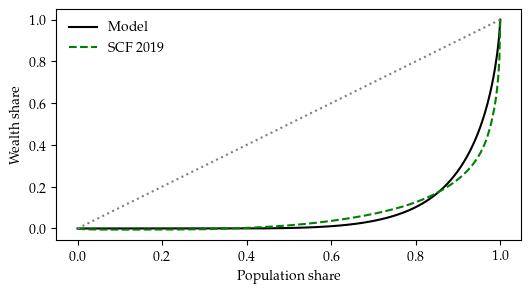

In [22]:
percentiles_detail = np.arange(501) / 500
lorenz_scf_detail = np.array([np.interp(pctl, lorenz_scf[:, 0], lorenz_scf[:, 1]) for pctl in percentiles_detail])
lorenz_model_detail = get_lorenz(ss, percentiles_detail)

plt.plot(percentiles_detail, lorenz_model_detail, label='Model', color='black')
plt.plot(percentiles_detail, lorenz_scf_detail, label='SCF 2019', linestyle='dashed', color='green')
plt.plot([0, 1], [0, 1], linestyle='dotted', color='gray')
plt.ylabel('Wealth share')
plt.xlabel('Population share')
plt.legend(frameon=False)
plt.savefig("figures/lecture1_fig6.pdf", transparent=True, bbox_inches='tight')

## Dynamics: shocks to $Z_s$ in our model

Function calculating transition in response to paths of $r_t^p$ and $Z_t$:

In [23]:
def calculate_transition(rps, Zs):
    T = len(rps)
    
    # backward iteration to get policies
    Va = ss['Va']
    a, c = np.empty((T, *ss['a'].shape)), np.empty((T, *ss['c'].shape))
    for t in reversed(range(T)):
        Va, a[t], c[t] = sim.backward_iteration(**{**calib, 'Va': Va, 'y': e*Zs[t], 'r': rps[t]})

    # forward iteration to get distributions and aggregates
    D = ss['D']
    A, C = np.empty(T), np.empty(T)
    for t in range(T):
        A[t], C[t] = np.vdot(a[t], D), np.vdot(c[t], D)
        a_i, a_pi = sim.interpolate_lottery_loop(a[t], a_grid)
        D = sim.forward_iteration(D, Pi, a_i, a_pi)

    return A, C

Shocks to $Z_t$ at different dates:

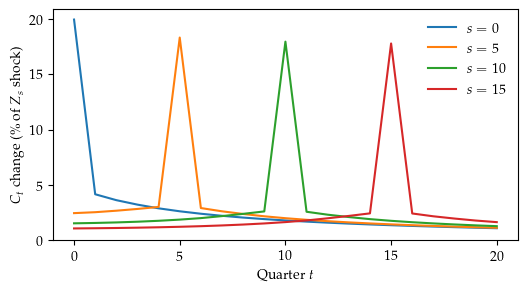

In [24]:
for s in (0, 5, 10, 15):
    Zs = 0.7*(1 + 0.001*(np.arange(21)==s))
    rps = np.ones_like(Zs) * r
    A, C = calculate_transition(rps, Zs)
    plt.plot(100*(C-ss['C']) / 0.001 / 0.7, label=fr'$s={s}$')
plt.xlabel(r'Quarter $t$')
plt.xticks([0, 5, 10, 15, 20])
plt.yticks([0, 5, 10, 15, 20])
plt.ylabel(r'$C_t$ change (\% of $Z_s$ shock)')
plt.legend(frameon=False)
plt.savefig("figures/lecture1_fig7.pdf", transparent=True, bbox_inches='tight')

Same for shocks to $r_t^p$ at different dates:

Implied MPC out of capital loss: -0.011


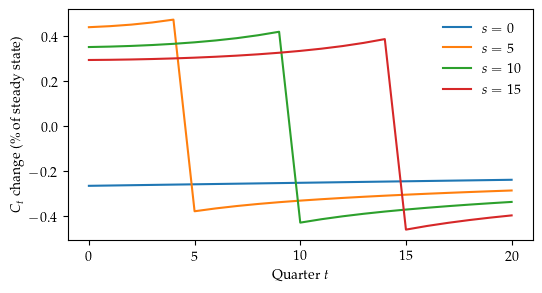

In [25]:
for s in (0, 5, 10, 15):
    Zs = np.ones_like(Zs) * 0.7
    rps = np.ones_like(Zs) * r - 0.01*(np.arange(21)==s)
    A, C = calculate_transition(rps, Zs)
    plt.plot(100*(C-ss['C']) / ss['C'], label=fr'$s={s}$')
    if s == 0:
        print(f"Implied MPC out of capital loss: {(C[0]-ss['C'])/(0.01*ss['A']):.3f}")
plt.xlabel(r'Quarter $t$')
plt.xticks([0, 5, 10, 15, 20])
plt.ylabel(r'$C_t$ change (\% of steady state)')
plt.legend(frameon=False)
plt.savefig("figures/lecture1_fig8.pdf", transparent=True, bbox_inches='tight')